In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from helpers import *
from missing_features_helper import DropHighMissingFeatures

In [2]:
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RepeatedStratifiedKFold
from sklearn.preprocessing import PowerTransformer #  Example: PowerTransformer(method='box-cox', standardize=False)
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer, KNNImputer
# explicitly require this experimental feature
from sklearn.experimental import enable_iterative_imputer  # noqa
# now you can import normally from sklearn.impute
from sklearn.impute import IterativeImputer

In [3]:
pd.set_option('display.max_columns', None)   
pd.set_option('display.max_rows', None)   

## Importing the data and merging it

In [4]:
data = pd.read_csv('../raw_data/secom.data', header=None, delimiter=" ")
labels = pd.read_csv('../raw_data/secom_labels.data', header=None, delimiter=" ")

In [5]:
data.shape

(1567, 590)

In [6]:
data.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504,505,506,507,508,509,510,511,512,513,514,515,516,517,518,519,520,521,522,523,524,525,526,527,528,529,530,531,532,533,534,535,536,537,538,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,578,579,580,581,582,583,584,585,586,587,588,589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,-0.0034,0.9455,202.4396,0.0,7.9558,414.8710,10.0433,0.9680,192.3963,12.5190,1.4026,-5419.00,2916.50,-4043.75,751.00,0.8955,1.7730,3.0490,64.2333,2.0222,0.1632,3.5191,83.3971,9.5126,50.6170,64.2588,49.3830,66.3141,86.9555,117.5132,61.29,4.515,70.0,352.7173,10.1841,130.3691,723.3092,1.3072,141.2282,1.0,624.3145,218.3174,0.0,4.592,4.841,2834.0,0.9317,0.9484,4.7057,-1.7264,350.9264,10.6231,108.6427,16.1445,21.7264,29.5367,693.7724,0.9226,148.6009,1.0,608.1700,84.0793,NaN,NaN,0.0,0.0126,-0.0206,0.0141,-0.0307,-0.0083,-0.0026,-0.0567,-0.0044,7.2163,0.1320,NaN,2.3895,0.9690,1747.6049,0.1841,8671.9301,-0.3274,-0.0055,-0.0001,0.0001,0.0003,-0.2786,0.0,0.3974,-0.0251,0.0002,0.0002,0.1350,-0.0042,0.0003,0.0056,0.0000,-0.2468,0.3196,NaN,NaN,NaN,NaN,0.9460,0.0,748.6115,0.9908,58.4306,0.6002,0.9804,6.3788,15.88,2.639,15.94,15.93,0.8656,3.353,0.4098,3.188,-0.0473,0.7243,0.9960,2.2967,1000.7263,39.2373,123.0,111.3,75.2,46.2000,350.6710,0.3948,0.0,6.78,0.0034,0.0898,0.0850,0.0358,0.0328,12.2566,0.0,4.271,10.284,0.4734,0.0167,11.8901,0.41,0.0506,NaN,NaN,1017.0,967.0,1066.0,368.0,0.090,0.048,0.095,2.0,0.9,0.069,0.046,0.7250,0.1139,0.3183,0.5888,0.3184,0.9499,0.3979,0.160,0.0,0.0,20.95,0.333,12.49,16.713,0.0803,5.72,0.0,11.19,65.363,0.0,0.0,0.0,0.0,0.0,0.0,0.292,5.38,20.10,0.296,10.62,10.30,5.38,4.040,16.230,0.2951,8.64,0.0,10.30,97.314,0.0,0.0772,0.0599,0.0700,0.0547,0.0704,0.0520,0.0301,0.1135,3.4789,0.0010,NaN,0.0707,0.0211,175.2173,0.0315,1940.3994,0.0,0.0744,0.0546,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0027,0.0040,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0188,0.0,219.9453,0.0011,2.8374,0.0189,0.0050,0.4269,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0472,40.855

In [7]:
labels.head()

,0,1
0,-1,19/07/2008 11:55:00
1,-1,19/07/2008 12:32:00
2,1,19/07/2008 13:17:00
3,-1,19/07/2008 14:43:00
4,-1,19/07/2008 15:22:00


In [8]:
labels.shape

(1567, 2)

### Rename label columns 

In [9]:
labels = labels.rename({0: "Label", 1: "timestamp"}, axis='columns')

In [10]:
df = data.merge(labels, left_index=True, right_index=True)

In [11]:
df.shape

(1567, 592)

In [12]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504,505,506,507,508,509,510,511,512,513,514,515,516,517,518,519,520,521,522,523,524,525,526,527,528,529,530,531,532,533,534,535,536,537,538,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,578,579,580,581,582,583,584,585,586,587,588,589,Label,timestamp
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,-0.0034,0.9455,202.4396,0.0,7.9558,414.8710,10.0433,0.9680,192.3963,12.5190,1.4026,-5419.00,2916.50,-4043.75,751.00,0.8955,1.7730,3.0490,64.2333,2.0222,0.1632,3.5191,83.3971,9.5126,50.6170,64.2588,49.3830,66.3141,86.9555,117.5132,61.29,4.515,70.0,352.7173,10.1841,130.3691,723.3092,1.3072,141.2282,1.0,624.3145,218.3174,0.0,4.592,4.841,2834.0,0.9317,0.9484,4.7057,-1.7264,350.9264,10.6231,108.6427,16.1445,21.7264,29.5367,693.7724,0.9226,148.6009,1.0,608.1700,84.0793,NaN,NaN,0.0,0.0126,-0.0206,0.0141,-0.0307,-0.0083,-0.0026,-0.0567,-0.0044,7.2163,0.1320,NaN,2.3895,0.9690,1747.6049,0.1841,8671.9301,-0.3274,-0.0055,-0.0001,0.0001,0.0003,-0.2786,0.0,0.3974,-0.0251,0.0002,0.0002,0.1350,-0.0042,0.0003,0.0056,0.0000,-0.2468,0.3196,NaN,NaN,NaN,NaN,0.9460,0.0,748.6115,0.9908,58.4306,0.6002,0.9804,6.3788,15.88,2.639,15.94,15.93,0.8656,3.353,0.4098,3.188,-0.0473,0.7243,0.9960,2.2967,1000.7263,39.2373,123.0,111.3,75.2,46.2000,350.6710,0.3948,0.0,6.78,0.0034,0.0898,0.0850,0.0358,0.0328,12.2566,0.0,4.271,10.284,0.4734,0.0167,11.8901,0.41,0.0506,NaN,NaN,1017.0,967.0,1066.0,368.0,0.090,0.048,0.095,2.0,0.9,0.069,0.046,0.7250,0.1139,0.3183,0.5888,0.3184,0.9499,0.3979,0.160,0.0,0.0,20.95,0.333,12.49,16.713,0.0803,5.72,0.0,11.19,65.363,0.0,0.0,0.0,0.0,0.0,0.0,0.292,5.38,20.10,0.296,10.62,10.30,5.38,4.040,16.230,0.2951,8.64,0.0,10.30,97.314,0.0,0.0772,0.0599,0.0700,0.0547,0.0704,0.0520,0.0301,0.1135,3.4789,0.0010,NaN,0.0707,0.0211,175.2173,0.0315,1940.3994,0.0,0.0744,0.0546,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0027,0.0040,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0188,0.0,219.9453,0.0011,2.8374,0.0189,0.0050,0.4269,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

## Phase 2: Initial Data Inspection

#### Count rows, columns, pass examples, fail examples, and failure percentage.

In [13]:
# Rows and Columns count
print(f'Amount of rows {df.shape[0]}')
print(f'Amount of columns {df.shape[1]}')

Amount of rows 1567
Amount of columns 592


In [14]:
pass_fail = df.Label.value_counts()

In [15]:
df.Label.value_counts(normalize=True)

Label
-1    0.933631
 1    0.066369
Name: proportion, dtype: float64

In [16]:
print(f'Pass example count {pass_fail[-1]} that is 93.3631% of the total')
print(f'Fail example count {pass_fail[1]} that is the 6.6369% of the total')

Pass example count 1463 that is 93.3631% of the total
Fail example count 104 that is the 6.6369% of the total


### Checking for null values

In [17]:
df.isnull().sum()

0               6
1               7
2              14
3              14
4              14
5              14
6              14
7               9
8               2
9               2
10              2
11              2
12              2
13              3
14              3
15              3
16              3
17              3
18              3
19             10
20              0
21              2
22              2
23              2
24              2
25              2
26              2
27              2
28              2
29              2
30              2
31              2
32              1
33              1
34              1
35              1
36              1
37              1
38              1
39              1
40             24
41             24
42              1
43              1
44              1
45              1
46              1
47              1
48              1
49              1
50              1
51              1
52              1
53              4
54              4
55        

##### Total of null values

In [18]:
df.isnull().sum().sum()

np.int64(41951)

### Identify constant and near-constant features.

>Constant features are identified as columns with one or fewer unique non-missing values. Near-constant features are identified as columns where one observed value accounted for at least 98% of the non-missing observations. These features are reviewed because they provide little variation for distinguishing pass and fail examples.

In [19]:
report = constant_near_constant_report(df.drop(columns=["Label"]), near_constant_threshold=0.98)

In [20]:
report.head()

,feature,n_rows,n_missing,missing_rate,n_unique_non_missing,n_unique_including_missing,most_common_value,most_common_count,dominance_rate_non_missing,dominance_rate_total,is_constant,is_near_constant
5,5,1567,14,0.008934,1,2,100.0,1553,1.0,0.991066,True,False
13,13,1567,3,0.001914,1,2,0.0,1564,1.0,0.998086,True,False
42,42,1567,1,0.000638,1,2,70.0,1566,1.0,0.999362,True,False
49,49,1567,1,0.000638,1,2,1.0,1566,1.0,0.999362,True,False
52,52,1567,1,0.000638,1,2,0.0,1566,1.0,0.999362,True,False


#### Maximum number of null values in the "is_constant" columns

In [21]:
report[report['is_constant'] == True]['n_missing'].max()

np.int64(24)

In [22]:
report[report['is_constant'] == True]['n_unique_including_missing'].max()

np.int64(2)

Only 2 values in the "is_constant" cols. 1 value and the NaN values. Those columns will be removed

#### Columns names when the values are constant 

In [23]:
constant_features = report[report['is_constant'] == True]['feature'].values
constant_features

array([5, 13, 42, 49, 52, 69, 97, 141, 149, 178, 179, 186, 189, 190, 191,
       192, 193, 194, 226, 229, 230, 231, 232, 233, 234, 235, 236, 237,
       240, 241, 242, 243, 256, 257, 258, 259, 260, 261, 262, 263, 264,
       265, 266, 276, 284, 313, 314, 315, 322, 325, 326, 327, 328, 329,
       330, 364, 369, 370, 371, 372, 373, 374, 375, 378, 379, 380, 381,
       394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 404, 414, 422,
       449, 450, 451, 458, 461, 462, 463, 464, 465, 466, 481, 498, 501,
       502, 503, 504, 505, 506, 507, 508, 509, 512, 513, 514, 515, 528,
       529, 530, 531, 532, 533, 534, 535, 536, 537, 538], dtype=object)

#### Near constant features

In [24]:
report[report['is_near_constant'] == True]

,feature,n_rows,n_missing,missing_rate,n_unique_non_missing,n_unique_including_missing,most_common_value,most_common_count,dominance_rate_non_missing,dominance_rate_total,is_constant,is_near_constant
74,74,1567,6,0.003829,2,3,0.0,1560,0.999359,0.995533,False,True
206,206,1567,6,0.003829,2,3,0.0,1560,0.999359,0.995533,False,True
209,209,1567,6,0.003829,2,3,0.0,1560,0.999359,0.995533,False,True
342,342,1567,6,0.003829,2,3,0.0,1560,0.999359,0.995533,False,True
347,347,1567,6,0.003829,2,3,0.0,1560,0.999359,0.995533,False,True
478,478,1567,6,0.003829,2,3,0.0,1560,0.999359,0.995533,False,True
521,521,1567,0,0.000000,9,9,0.0,1546,0.986599,0.986599,False,True
114,114,1567,0,0.000000,20,20,0.0,1545,0.985960,0.985960,False,True
249,249,1567,0,0.000000,23,23,0.0,1545,0.985960,0.985960,False,True
387,387,1567,0,0.000000,22,22,0.0,1545,0.985960,0.985960,False,True


In [25]:
df[13].unique()

array([ 0., nan])

In [26]:
near_constant_features = report.loc[(report["is_near_constant"] == True) & (report["n_unique_including_missing"] < 9), "feature"].tolist()

In [27]:
len(near_constant_features)

6

In [28]:
len(constant_features)

116

In [29]:
for threshold in [0.95, 0.98, 0.99]:
    report = constant_near_constant_report(df.drop(columns=["Label"]), near_constant_threshold=threshold)
    print(
        threshold,
        "constant:",
        report["is_constant"].sum(),
        "near-constant:",
        report["is_near_constant"].sum()
    )

0.95 constant: 116 near-constant: 10
0.98 constant: 116 near-constant: 10
0.99 constant: 116 near-constant: 6


In [30]:
len(list(constant_features) + near_constant_features)

122

In [31]:
df_no_constant_cols = df.drop(columns=list(constant_features) + near_constant_features)

In [32]:
df_no_constant_cols.head()

,0,1,2,3,4,6,7,8,9,10,11,12,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,43,44,45,46,47,48,50,51,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,70,71,72,73,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,142,143,144,145,146,147,148,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,180,181,182,183,184,185,187,188,195,196,197,198,199,200,201,202,203,204,205,207,208,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,227,228,238,239,244,245,246,247,248,249,250,251,252,253,254,255,267,268,269,270,271,272,273,274,275,277,278,279,280,281,282,283,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,316,317,318,319,320,321,323,324,331,332,333,334,335,336,337,338,339,340,341,343,344,345,346,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,365,366,367,368,376,377,382,383,384,385,386,387,388,389,390,391,392,393,405,406,407,408,409,410,411,412,413,415,416,417,418,419,420,421,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,452,453,454,455,456,457,459,460,467,468,469,470,471,472,473,474,475,476,477,479,480,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,499,500,510,511,516,517,518,519,520,521,522,523,524,525,526,527,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,578,579,580,581,582,583,584,585,586,587,588,589,Label,timestamp
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,97.6133,0.1242,1.5005,0.0162,-0.0034,0.9455,202.4396,7.9558,414.8710,10.0433,0.9680,192.3963,12.5190,1.4026,-5419.00,2916.50,-4043.75,751.00,0.8955,1.7730,3.0490,64.2333,2.0222,0.1632,3.5191,83.3971,9.5126,50.6170,64.2588,49.3830,66.3141,86.9555,117.5132,61.29,4.515,352.7173,10.1841,130.3691,723.3092,1.3072,141.2282,624.3145,218.3174,4.592,4.841,2834.0,0.9317,0.9484,4.7057,-1.7264,350.9264,10.6231,108.6427,16.1445,21.7264,29.5367,693.7724,0.9226,148.6009,608.1700,84.0793,NaN,NaN,0.0126,-0.0206,0.0141,-0.0307,-0.0083,-0.0026,-0.0567,-0.0044,7.2163,0.1320,NaN,2.3895,0.9690,1747.6049,0.1841,8671.9301,-0.3274,-0.0055,-0.0001,0.0001,0.0003,-0.2786,0.3974,-0.0251,0.0002,0.0002,0.1350,-0.0042,0.0003,0.0056,0.0000,-0.2468,0.3196,NaN,NaN,NaN,NaN,0.9460,0.0,748.6115,0.9908,58.4306,0.6002,0.9804,6.3788,15.88,2.639,15.94,15.93,0.8656,3.353,0.4098,3.188,-0.0473,0.7243,0.9960,2.2967,1000.7263,39.2373,123.0,111.3,75.2,46.2000,350.6710,0.3948,6.78,0.0034,0.0898,0.0850,0.0358,0.0328,12.2566,4.271,10.284,0.4734,0.0167,11.8901,0.41,0.0506,NaN,NaN,1017.0,967.0,1066.0,368.0,0.090,0.048,0.095,2.0,0.9,0.069,0.046,0.7250,0.1139,0.3183,0.5888,0.3184,0.9499,0.3979,0.160,20.95,0.333,12.49,16.713,0.0803,5.72,11.19,65.363,0.292,5.38,20.10,0.296,10.62,10.30,5.38,4.040,16.230,0.2951,8.64,10.30,97.314,0.0772,0.0599,0.0700,0.0547,0.0704,0.0520,0.0301,0.1135,3.4789,0.0010,NaN,0.0707,0.0211,175.2173,0.0315,1940.3994,0.0744,0.0546,0.0027,0.0040,NaN,NaN,NaN,NaN,0.0188,0.0,219.9453,0.0011,2.8374,0.0189,0.0050,0.4269,0.0472,40.855,4.5152,30.9815,33.9606,22.9057,15.9525,110.2144,0.1310,2.5883,0.0010,0.0319,0.0197,0.0120,0.0109,3.9321,1.5123,3.5811,0.1337,0.0055,3.8447,0.1077,0.0167,NaN,NaN,418.1363,398.3185,496.1582,158.3330,0.0373,0.0202,0.0462,0.6083,0.3032,0.0200,0.0174,0.2827,0.0434,0.1342,0.2419,0.1343,0.3670,0.1431,0.0610,6.2698,0.1181,3.8208,5.3737,0.0254,1.6252,3.2461,18.0118,0.0752,1.5989,6.5893,0.0913,3.0911,8.4654,1.5989,1.2293,5.3406,0.0867,2.8551,2.9971,31.8843,NaN,NaN,0.0215,0.0274,0.0315,0.0238,0.0206,0.0238,0.0144,0.0491,1.2708,0.0004,NaN,0.0229,0.0065,55.2039,0.0105,560.2658,0.0170,0.0148,0.0124,0.0114,0.0010,0.0013,NaN,NaN,NaN,NaN,0.0055,0.0,61.5932,0

## Phase 3: Missingness as Process Information

### Check duplicate rows and feature types

In [33]:
data.duplicated().sum()

np.int64(0)

No duplicate rows in the dataset

In [34]:
df_no_constant_cols.dtypes.value_counts()

float64    468
int64        1
str          1
Name: count, dtype: int64

In [35]:
print(f'Label column is integer (-1, 1) \nTimestamp column string (needs to be converted to datetime)\nThe rest of the columns are float data type')

Label column is integer (-1, 1) 
Timestamp column string (needs to be converted to datetime)
The rest of the columns are float data type


##### Convert datetime column fron string to datetime

In [36]:
df_no_constant_cols.timestamp = pd.to_datetime(df_no_constant_cols.timestamp, format="%d/%m/%Y %H:%M:%S")

In [37]:
df_no_constant_cols.head()

,0,1,2,3,4,6,7,8,9,10,11,12,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,43,44,45,46,47,48,50,51,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,70,71,72,73,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,142,143,144,145,146,147,148,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,180,181,182,183,184,185,187,188,195,196,197,198,199,200,201,202,203,204,205,207,208,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,227,228,238,239,244,245,246,247,248,249,250,251,252,253,254,255,267,268,269,270,271,272,273,274,275,277,278,279,280,281,282,283,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,316,317,318,319,320,321,323,324,331,332,333,334,335,336,337,338,339,340,341,343,344,345,346,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,365,366,367,368,376,377,382,383,384,385,386,387,388,389,390,391,392,393,405,406,407,408,409,410,411,412,413,415,416,417,418,419,420,421,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,452,453,454,455,456,457,459,460,467,468,469,470,471,472,473,474,475,476,477,479,480,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,499,500,510,511,516,517,518,519,520,521,522,523,524,525,526,527,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,578,579,580,581,582,583,584,585,586,587,588,589,Label,timestamp
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,97.6133,0.1242,1.5005,0.0162,-0.0034,0.9455,202.4396,7.9558,414.8710,10.0433,0.9680,192.3963,12.5190,1.4026,-5419.00,2916.50,-4043.75,751.00,0.8955,1.7730,3.0490,64.2333,2.0222,0.1632,3.5191,83.3971,9.5126,50.6170,64.2588,49.3830,66.3141,86.9555,117.5132,61.29,4.515,352.7173,10.1841,130.3691,723.3092,1.3072,141.2282,624.3145,218.3174,4.592,4.841,2834.0,0.9317,0.9484,4.7057,-1.7264,350.9264,10.6231,108.6427,16.1445,21.7264,29.5367,693.7724,0.9226,148.6009,608.1700,84.0793,NaN,NaN,0.0126,-0.0206,0.0141,-0.0307,-0.0083,-0.0026,-0.0567,-0.0044,7.2163,0.1320,NaN,2.3895,0.9690,1747.6049,0.1841,8671.9301,-0.3274,-0.0055,-0.0001,0.0001,0.0003,-0.2786,0.3974,-0.0251,0.0002,0.0002,0.1350,-0.0042,0.0003,0.0056,0.0000,-0.2468,0.3196,NaN,NaN,NaN,NaN,0.9460,0.0,748.6115,0.9908,58.4306,0.6002,0.9804,6.3788,15.88,2.639,15.94,15.93,0.8656,3.353,0.4098,3.188,-0.0473,0.7243,0.9960,2.2967,1000.7263,39.2373,123.0,111.3,75.2,46.2000,350.6710,0.3948,6.78,0.0034,0.0898,0.0850,0.0358,0.0328,12.2566,4.271,10.284,0.4734,0.0167,11.8901,0.41,0.0506,NaN,NaN,1017.0,967.0,1066.0,368.0,0.090,0.048,0.095,2.0,0.9,0.069,0.046,0.7250,0.1139,0.3183,0.5888,0.3184,0.9499,0.3979,0.160,20.95,0.333,12.49,16.713,0.0803,5.72,11.19,65.363,0.292,5.38,20.10,0.296,10.62,10.30,5.38,4.040,16.230,0.2951,8.64,10.30,97.314,0.0772,0.0599,0.0700,0.0547,0.0704,0.0520,0.0301,0.1135,3.4789,0.0010,NaN,0.0707,0.0211,175.2173,0.0315,1940.3994,0.0744,0.0546,0.0027,0.0040,NaN,NaN,NaN,NaN,0.0188,0.0,219.9453,0.0011,2.8374,0.0189,0.0050,0.4269,0.0472,40.855,4.5152,30.9815,33.9606,22.9057,15.9525,110.2144,0.1310,2.5883,0.0010,0.0319,0.0197,0.0120,0.0109,3.9321,1.5123,3.5811,0.1337,0.0055,3.8447,0.1077,0.0167,NaN,NaN,418.1363,398.3185,496.1582,158.3330,0.0373,0.0202,0.0462,0.6083,0.3032,0.0200,0.0174,0.2827,0.0434,0.1342,0.2419,0.1343,0.3670,0.1431,0.0610,6.2698,0.1181,3.8208,5.3737,0.0254,1.6252,3.2461,18.0118,0.0752,1.5989,6.5893,0.0913,3.0911,8.4654,1.5989,1.2293,5.3406,0.0867,2.8551,2.9971,31.8843,NaN,NaN,0.0215,0.0274,0.0315,0.0238,0.0206,0.0238,0.0144,0.0491,1.2708,0.0004,NaN,0.0229,0.0065,55.2039,0.0105,560.2658,0.0170,0.0148,0.0124,0.0114,0.0010,0.0013,NaN,NaN,NaN,NaN,0.0055,0.0,61.5932,0

#### Calculate missing percentage per feature.

In [38]:
col_50_pre_null_val = df_no_constant_cols.columns[df_no_constant_cols.isnull().mean() > 0.5]

In [39]:
len(col_50_pre_null_val)

28

There are 28 columns where missing percentage is greater than 50%

#### Compare missingness rates between pass and fail groups.

In [40]:
missingness_target_report = missingness_by_target_report(df_no_constant_cols.drop(columns='Label'), df_no_constant_cols.Label)

In [41]:
missingness_target_report['feature'].nunique()

469

In [42]:
(missingness_target_report.pass_missing_rate > 0.65).sum()

np.int64(8)

8 features with pass missing rate greater that 0.65 (almost the whole dataset)

In [43]:
missingness_target_report[(missingness_target_report.pass_missing_rate > 0.65)]

,feature,n_pass,n_fail,pass_missing_count,fail_missing_count,total_missing_count,pass_missing_rate,fail_missing_rate,missing_rate_diff_fail_minus_pass,fail_share_among_missing,all_fails_missing,missing_only_when_fail,perfect_failure_missing_signal,exact_match_fail_flag
78,85,1463,104,1248,93,1341,0.853042,0.894231,0.041189,0.069351,False,False,False,False
199,220,1463,104,1248,93,1341,0.853042,0.894231,0.041189,0.069351,False,False,False,False
298,358,1463,104,1248,93,1341,0.853042,0.894231,0.041189,0.069351,False,False,False,False
395,492,1463,104,1248,93,1341,0.853042,0.894231,0.041189,0.069351,False,False,False,False
147,157,1463,104,1333,96,1429,0.911141,0.923077,0.011935,0.067180,False,False,False,False
148,158,1463,104,1333,96,1429,0.911141,0.923077,0.011935,0.067180,False,False,False,False
244,292,1463,104,1333,96,1429,0.911141,0.923077,0.011935,0.067180,False,False,False,False
245,293,1463,104,1333,96,1429,0.911141,0.923077,0.011935,0.067180,False,False,False,False


In [44]:
print(f'Amount of features with all failures missing: {len(missingness_target_report[missingness_target_report["all_fails_missing"] == True])}')
print(f'Amount of features with missing values only when failure occurs: {len(missingness_target_report[missingness_target_report["missing_only_when_fail"] == True])}')

print(f'Amount of features with perfect failure missing signal: {len(missingness_target_report[missingness_target_report["perfect_failure_missing_signal"] == True])}')
print(f'Amount of features with exact match failure flag: {len(missingness_target_report[missingness_target_report["exact_match_fail_flag"] == True])}')

Amount of features with all failures missing: 0
Amount of features with missing values only when failure occurs: 0
Amount of features with perfect failure missing signal: 0
Amount of features with exact match failure flag: 0


In [45]:
print(f'Amount of features with exact match fail flag: {len(missingness_target_report[missingness_target_report["exact_match_fail_flag"] == True])}')

Amount of features with exact match fail flag: 0


In [46]:
print(f'Amount of features with missing rate difference between failure and pass: {len(missingness_target_report[missingness_target_report["missing_rate_diff_fail_minus_pass"] == True])}')

Amount of features with missing rate difference between failure and pass: 0


## What this table means

Each feature is evaluated on:
- `pass_missing_rate`: fraction of pass rows where the feature is missing
- `fail_missing_rate`: fraction of fail rows where the feature is missing
- `missing_rate_diff_fail_minus_pass`: how much more often the feature is missing in fails vs passes
- `fail_share_among_missing`: among rows where the feature is missing, what share are failures

It also flags suspicious patterns:
- `all_fails_missing`: every failing row has this feature missing
- `missing_only_when_fail`: only failing rows have missing values for this feature
- `perfect_failure_missing_signal`: missingness perfectly separates fail vs pass
- `exact_match_fail_flag`: missing pattern exactly matches the failure label

---

## What the sample output shows

From the rows shown:
- Features like `109, 110, 111, 244, 245, 246, 382, 383, 384, 516, 517, 518`
  - have very high missingness overall
  - are missing slightly more often in fails than passes
  - but do not trigger any extreme leakage flags
- Features `562`–`569` show a similar pattern at lower overall missingness
- Feature `85` is missing in most rows and also has only a small fail/pass difference

So these are likely “features with a missingness signal,” not “features that perfectly leak the label.”

---

## Key interpretation

- A feature with `fail_missing_rate > pass_missing_rate` may be informative, but it is not necessarily a safe predictive feature.
- The most suspicious cases are when:
  - `perfect_failure_missing_signal == True`, or
  - `exact_match_fail_flag == True`, or
  - `missing_only_when_fail == True`
- The shown rows do not appear to be the extreme leakage cases.

---

## Recommendation

For a stronger conclusion:
1. check whether any rows in `missingness_target_report` have `perfect_failure_missing_signal == True`
2. check whether any rows have `exact_match_fail_flag == True`
3. review features with the highest `missing_rate_diff_fail_minus_pass`

> No desicion about the missigness will be made at this time

In [47]:
(df_no_constant_cols.isnull().sum()).sort_values(ascending=False).head(10)

292    1429
158    1429
157    1429
293    1429
85     1341
358    1341
220    1341
492    1341
516    1018
109    1018
dtype: int64

In [48]:
len(df_no_constant_cols.columns)

470

In [49]:
1429 /  df_no_constant_cols.shape[0]

0.9119336311423102

There are several columns that have more than 90% of missing values.

In [50]:
feature_to_drop_due_to_missignes = list(missingness_target_report[(missingness_target_report.pass_missing_rate > 0.65)]['feature'])

### Dropping features with more that 80% of issing values (that happend to be greater that 65%)

In [51]:
df_no_constant_cols = df_no_constant_cols.drop(columns=feature_to_drop_due_to_missignes)

## Phase 4: Target Imbalance and Manufacturing Risk

In [52]:
df_no_constant_cols.Label.value_counts()

Label
-1    1463
 1     104
Name: count, dtype: int64

> Pass example count 1463 that is 93.36% of the total <br>
> Fail example count 104 that is the 6.64% of the total

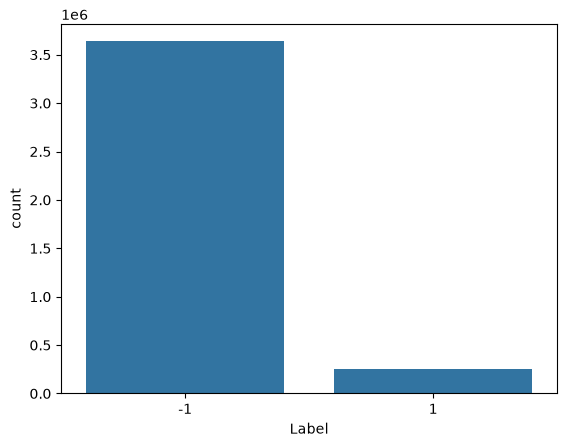

In [53]:
sns.countplot(df_no_constant_cols, x='Label');

| Class | Label | Count | Percentage |
| ----- | ----: | ----: | ---------: |
| Pass  |    -1 | 1,463 |     93.36% |
| Fail  |     1 |   104 |      6.64% |

### Phase 5

In [ ]:
df_no_constant_cols.describe().T

In [ ]:
eda_report = build_feature_eda_report(
    X=df_no_constant_cols.drop(columns=["Label", "timestamp"]),
    y=df_no_constant_cols.Label
)

In [ ]:
eda_report.shape

In [ ]:
eda_report.outlier_count.median()

### Which features differ most between pass and fail?

In [ ]:
pass_fail_candidates = (
    eda_report
    .sort_values(
        "abs_standardized_mean_difference",
        ascending=False
    )
    .head(30)
)

pass_fail_candidates[
    [
        "feature",
        "pass_mean",
        "fail_mean",
        "standardized_mean_difference",
    ]
]

In [ ]:
features_differ_most_between_pass_and_fail = pass_fail_candidates.feature

In [ ]:
len(features_differ_most_between_pass_and_fail)

### Which features have failures in extreme ranges?

In [ ]:
failure_extreme_candidates = (
    eda_report
    .sort_values(
        "fail_extreme_rate",
        ascending=False
    )
    .head(30)
)

failure_extreme_candidates[
    [
        "feature",
        "pass_lower_5pct",
        "pass_upper_95pct",
        "fail_extreme_rate",
        "fail_low_extreme_rate",
        "fail_high_extreme_rate",
    ]
].sort_values("fail_extreme_rate", ascending=False)

In [ ]:
features_have_failures_in_extreme_ranges = failure_extreme_candidates.feature

### Which features are strongly skewed?

In [ ]:
skewed_features = (
    eda_report
    .assign(abs_skew=lambda d: d["skew"].abs())
    .sort_values(
        "abs_skew",
        ascending=False
    )
    .head(30)
)

In [ ]:
features_are_strongly_skewed = skewed_features.feature

In [ ]:
outlier_candidates = (
    eda_report
    .sort_values(
        "outlier_rate",
        ascending=False
    )
    .head(30)
)

outlier_candidates[
    [
        "feature",
        "outlier_count",
        "outlier_rate",
        "skew",
    ]
]

In [ ]:
features_with_higher_outliers_rate = outlier_candidates.feature

In [ ]:
eda_report = add_behavior_flags(
    eda_report
)

In [ ]:
eda_report[
    "candidate_process_signal"
].value_counts()

In [ ]:
candidate_features = eda_report[
    eda_report["candidate_process_signal"]
].copy()

candidate_features.shape

In [ ]:
eda_report["eda_priority_score"] = (
    eda_report[
        "abs_standardized_mean_difference"
    ].fillna(0)
    +
    eda_report[
        "fail_extreme_rate"
    ].fillna(0)
    +
    eda_report[
        "outlier_rate"
    ].fillna(0)
)

In [ ]:
eda_shortlist = (
    eda_report
    .sort_values(
        "eda_priority_score",
        ascending=False
    )
    .head(30)
)

eda_shortlist[
    [
        "feature",
        "missing_rate",
        "abs_standardized_mean_difference",
        "fail_extreme_rate",
        "outlier_rate",
        "skew",
        "eda_priority_score",
    ]
]

In [ ]:
features_to_plot = [
    59,
    348,
    103,
    510,
    431,
    430,
    64,
    65,
    129,
    562,
    21,
    28,
]

In [ ]:
for feature in features_to_plot:
    sns.histplot(
        data=df_no_constant_cols,
        x=feature,
        hue="Label",
        kde=True,
        stat="density",
        common_norm=False
    )

    plt.title(f"Feature {feature}: Pass vs Fail")
    plt.show()


### Features intersect 

In [ ]:
set(features_differ_most_between_pass_and_fail) & set(features_have_failures_in_extreme_ranges)

In [ ]:
set(features_differ_most_between_pass_and_fail) & set(features_are_strongly_skewed)

In [ ]:
set(features_differ_most_between_pass_and_fail) & set(features_with_higher_outliers_rate)

In [ ]:
set(features_have_failures_in_extreme_ranges) & set(features_are_strongly_skewed)

In [ ]:
set(features_have_failures_in_extreme_ranges) & set(features_with_higher_outliers_rate)

In [ ]:
set(features_are_strongly_skewed) & set(features_with_higher_outliers_rate)